# Volatility Benchmarking & Ensemble Methods

This notebook serves as the culmination of the modeling phase. Here, we bring together all the models we have trained so far: from Classical Machine Learning (Ridge, Random Forest, XGBoost, LightGBM) to Deep Learning (LSTM, GRU), and evaluate them on a unified, perfectly aligned test set. 

**Key Steps:**
1. **Model Aggregation:** Load all saved models and scalers.
2. **Unified Evaluation:** Map all predictions to a single `eval_df` DataFrame, ensuring strict temporal alignment.
3. **Ensemble Engineering:** Combine predictions using various ensemble strategies (Simple Average, Boosting-Only, and Weighted Averaging) to create a meta-model that outperforms individual algorithms.
4. **Benchmarking & Visualization:** Compare Root Mean Squared Error (RMSE) across all approaches and visualize the residual errors.

In [1]:
# Standard libraries
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# PyTorch
import torch
import torch.nn as nn

# PyTorch Forecasting (for TFT)
import lightning.pytorch as pl
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer

# Ignore warnings for cleaner output
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 6)

### Configuration & Architecture Redefinition

To load a PyTorch `.pth` state dictionary, the original class definitions must exist in the current namespace. We redefine the `VolatilityLSTM` and `VolatilityGRU` architectures exactly as they were built during training.

In [2]:
# Configuration
DATA_PATH = '../data/quantitative_market_dataset.csv'
MODELS_DIR = '../models/'
SEQ_LENGTH = 20

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# We MUST redefine the PyTorch classes here to load their state_dicts
class VolatilityLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, output_size=1):
        super(VolatilityLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

class VolatilityGRU(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, output_size=1):
        super(VolatilityGRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

Using device: cpu


### Global Data Preparation & Alignment

To compare models fairly, they must be tested on the exact same records. We load the dataset, apply the same temporal split (80/20) used in training, and initialize a `Master Evaluation DataFrame` containing only the test set's actual target values.

In [3]:
print("Loading and preparing dataset for global evaluation...")
df = pd.read_csv(DATA_PATH, parse_dates=['Date'])
df = df.sort_values(by=['ticker', 'Date']).reset_index(drop=True)

# Create Target and Lags (Lags are only needed for ML models)
df['target_volatility'] = df.groupby('ticker')['historical_volatility_20d'].shift(-1)
df['log_return_lag1'] = df.groupby('ticker')['log_return'].shift(1)
df['volatility_lag1'] = df.groupby('ticker')['historical_volatility_20d'].shift(1)
df = df.dropna().reset_index(drop=True)

# Categorical mapping
df = pd.get_dummies(df, columns=['asset_class'], drop_first=True)

# Define specific feature sets for ML and DL
ml_features = [col for col in df.columns if col not in ['Date', 'ticker', 'Open', 'High', 'Low', 'Close', 'target_volatility', 'simple_return']]
dl_features = [col for col in ml_features if col not in ['log_return_lag1', 'volatility_lag1']]

# Train/Test Split (Temporal)
df_sorted = df.sort_values('Date').reset_index(drop=True)
split_idx = int(len(df_sorted) * 0.8)
split_date = df_sorted.loc[split_idx, 'Date']

# Isolate Test Set
test_df = df[df['Date'] >= split_date].copy().reset_index(drop=True)

# Initialize the Master Evaluation DataFrame
eval_df = test_df[['Date', 'ticker', 'target_volatility']].copy()
eval_df.rename(columns={'target_volatility': 'Actual'}, inplace=True)

print(f"Evaluation DataFrame ready. Shape: {eval_df.shape}")
print(f"ML Features: {len(ml_features)} | DL Features: {len(dl_features)}")

Loading and preparing dataset for global evaluation...
Evaluation DataFrame ready. Shape: (22675, 3)
ML Features: 10 | DL Features: 8


### Evaluating Classical Machine Learning Models

We load our previously saved Machine Learning models and their specific `StandardScaler`. We generate predictions for the entire test set and append them as new columns in our master evaluation table.

In [4]:
print("Evaluating Classical Machine Learning Models...")

# Load ML Scaler
ml_scaler = joblib.load(os.path.join(MODELS_DIR, 'ml_feature_scaler.pkl'))
X_test_scaled = ml_scaler.transform(test_df[ml_features])

ml_models = ['ridge', 'randomforest', 'xgboost', 'lightgbm']

for model_name in ml_models:
    model_path = os.path.join(MODELS_DIR, f'{model_name}.pkl')
    try:
        # Load the model from disk
        model = joblib.load(model_path)
        # Generate predictions
        preds = model.predict(X_test_scaled)
        # Store predictions in the master DataFrame
        eval_df[f'Pred_{model_name.upper()}'] = preds
        print(f"  [+] {model_name.upper()} loaded and predicted.")
    except FileNotFoundError:
        print(f"  [-] {model_name.upper()} not found. Skipping.")

display(eval_df.head(3))

Evaluating Classical Machine Learning Models...
  [+] RIDGE loaded and predicted.
  [+] RANDOMFOREST loaded and predicted.
  [+] XGBOOST loaded and predicted.
  [+] LIGHTGBM loaded and predicted.


,Date,ticker,Actual,Pred_RIDGE,Pred_RANDOMFOREST,Pred_XGBOOST,Pred_LIGHTGBM
0,2021-12-28,AGG,0.030589,0.030213,0.025606,0.032616,0.030692
1,2021-12-29,AGG,0.031792,0.031413,0.025606,0.032616,0.031128
2,2021-12-30,AGG,0.031799,0.032555,0.032821,0.034657,0.032382


### Evaluating Sequential Deep Learning Models

Deep Learning models (LSTM/GRU) require 3D sequences. Generating sequences "consumes" the first `SEQ_LENGTH` (20) days of the test set, meaning they have fewer predictions than the ML models. To solve this, we track the exact `index` of each prediction and map it back to `eval_df` securely.

In [5]:
print("Evaluating Sequential Deep Learning Models...")

# Load DL Scaler
dl_scaler = joblib.load(os.path.join(MODELS_DIR, 'dl_feature_scaler.pkl'))
test_df_dl = test_df.copy()
test_df_dl[dl_features] = dl_scaler.transform(test_df_dl[dl_features])

# Generate sequences and map them to their exact original indices
X_dl, valid_indices = [], []

for ticker, group in test_df_dl.groupby('ticker'):
    features_array = group[dl_features].values
    # We can only predict from index SEQ_LENGTH onwards for each ticker
    for i in range(len(group) - SEQ_LENGTH):
        X_dl.append(features_array[i:(i + SEQ_LENGTH)])
        valid_indices.append(group.index[i + SEQ_LENGTH])

X_dl_tensor = torch.tensor(np.array(X_dl), dtype=torch.float32).to(device)

# Load Models
input_dim = len(dl_features)
lstm = VolatilityLSTM(input_dim).to(device)
gru = VolatilityGRU(input_dim).to(device)

lstm.load_state_dict(torch.load(os.path.join(MODELS_DIR, 'lstm_volatility.pth')))
gru.load_state_dict(torch.load(os.path.join(MODELS_DIR, 'gru_volatility.pth')))
lstm.eval(); gru.eval()

# Predict in a single batch (no gradients needed)
with torch.no_grad():
    lstm_preds = lstm(X_dl_tensor).cpu().numpy().flatten()
    gru_preds = gru(X_dl_tensor).cpu().numpy().flatten()

# Map predictions back to the Master DataFrame using the tracked indices
eval_df.loc[valid_indices, 'Pred_LSTM'] = lstm_preds
eval_df.loc[valid_indices, 'Pred_GRU'] = gru_preds

print(f"  [+] LSTM and GRU mapped to eval_df successfully.")

Evaluating Sequential Deep Learning Models...
  [+] LSTM and GRU mapped to eval_df successfully.


**Note for the TFT Model:**

Because TFT uses PyTorch Forecasting's TimeSeriesDataSet (which handles its own internal 
indexing, normalizers, and time_idx), injecting its predictions directly into this row-by-row 
eval_df can lead to misalignment errors. 

Performance metrics for TFT are added manually.

In [6]:
# Drop rows with NaNs (The first 20 days of each ticker lacked DL predictions)
eval_df = eval_df.dropna().reset_index(drop=True)
print(f"Final aligned evaluation dataset contains {len(eval_df)} samples.")

Final aligned evaluation dataset contains 22275 samples.


### Ensemble Engineering

Ensemble learning combines predictions from multiple models to reduce variance and improve robustness. We test three strategies:
1. **Simple Mean:** A straight average of our top-performing linear, boosting, and sequential models.
2. **Boosting Only:** Averaging XGBoost and LightGBM.
3. **Weighted Ensemble:** Assigning custom weights to models based on their historical reliability and strengths.

In [7]:
print("Constructing Dynamic Ensembles...")

# Get all base predictions
base_preds = [col for col in eval_df.columns if col.startswith('Pred_')]

# Calculate MSE for each base model to use as weighting factor
print("Calculating base performance for weights...")
mses = {}
for col in base_preds:
    mses[col] = mean_squared_error(eval_df['Actual'], eval_df[col])

# 1. Dynamic Weighted Ensemble (Inverse MSE Weighting)
# Better models (lower MSE) get exponentially higher weights
inv_mses = {col: 1.0 / mse for col, mse in mses.items()}
sum_inv_mses = sum(inv_mses.values())
weights = {col: inv_mse / sum_inv_mses for col, inv_mse in inv_mses.items()}

print("\nDynamic Weights applied (Sum = 100%):")
for col, w in sorted(weights.items(), key=lambda item: item[1], reverse=True):
    print(f"  {col.replace('Pred_', '')}: {w*100:.2f}%")

eval_df['Ens_Weighted_All'] = sum(eval_df[col] * w for col, w in weights.items())

# 2. Simple Mean Ensemble (Averaging all models equally)
eval_df['Ens_Simple_All'] = eval_df[base_preds].mean(axis=1)

# 3. Top-2 Models Ensemble (Average of the best two models only)
top_2_cols = sorted(mses, key=mses.get)[:2]
eval_df['Ens_Top_2'] = eval_df[top_2_cols].mean(axis=1)

print("\nEnsembles created successfully.")

Constructing Dynamic Ensembles...
Calculating base performance for weights...

Dynamic Weights applied (Sum = 100%):
  RIDGE: 20.58%
  RANDOMFOREST: 19.97%
  XGBOOST: 19.69%
  LIGHTGBM: 18.29%
  LSTM: 11.94%
  GRU: 9.53%

Ensembles created successfully.


### Global Benchmarking & Metrics Calculation

We iterate through all generated prediction columns, calculate our core metrics (RMSE, MAE, R²), and sort the final leaderboard to discover which model (or ensemble) reigns supreme.

In [8]:
# Get all prediction columns
pred_cols = [col for col in eval_df.columns if col.startswith('Pred_') or col.startswith('Ens_')]

results = []
for col in pred_cols:
    rmse = np.sqrt(mean_squared_error(eval_df['Actual'], eval_df[col]))
    mae = mean_absolute_error(eval_df['Actual'], eval_df[col])
    r2 = r2_score(eval_df['Actual'], eval_df[col])

    # Format the name for presentation
    results.append({
        'Raw_Column': col, # Stored to extract the best one dynamically
        'Model': col.replace('Pred_', '').replace('Ens_', 'Ensemble: '),
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })

# IInject TFT metrics manually, hardcoded from notebook 07_volatility_dl_attention.ipynb
results.append({
    'Raw_Column': 'TFT_Hardcoded', 
    'Model': 'TFT',
    'RMSE': 0.02942,
    'MAE': 0.01552,
    'R2': 0.97371
})

# Convert to DataFrame and sort by best RMSE
results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)

print("--- GLOBAL BENCHMARKING RESULTS ---")
display(results_df[['Model', 'RMSE', 'MAE', 'R2']])

--- GLOBAL BENCHMARKING RESULTS ---


,Model,RMSE,MAE,R2
0,Ensemble: Weighted_All,0.021249,0.010013,0.984826
1,Ensemble: Simple_All,0.021250,0.010558,0.984825
2,RIDGE,0.022577,0.009804,0.982870
3,Ensemble: Top_2,0.022611,0.009777,0.982819
4,RANDOMFOREST,0.022918,0.010176,0.982349
5,XGBOOST,0.023083,0.010231,0.982094
6,LIGHTGBM,0.023951,0.010965,0.980722
7,TFT,0.029420,0.015520,0.973710
8,LSTM,0.029643,0.016022,0.970470
9,GRU,0.033188,0.017814,0.962985


### Visualizing Performance and Residuals

Plotting dynamically: Best Model (Ensemble: Weighted_All) vs Baseline (RIDGE)


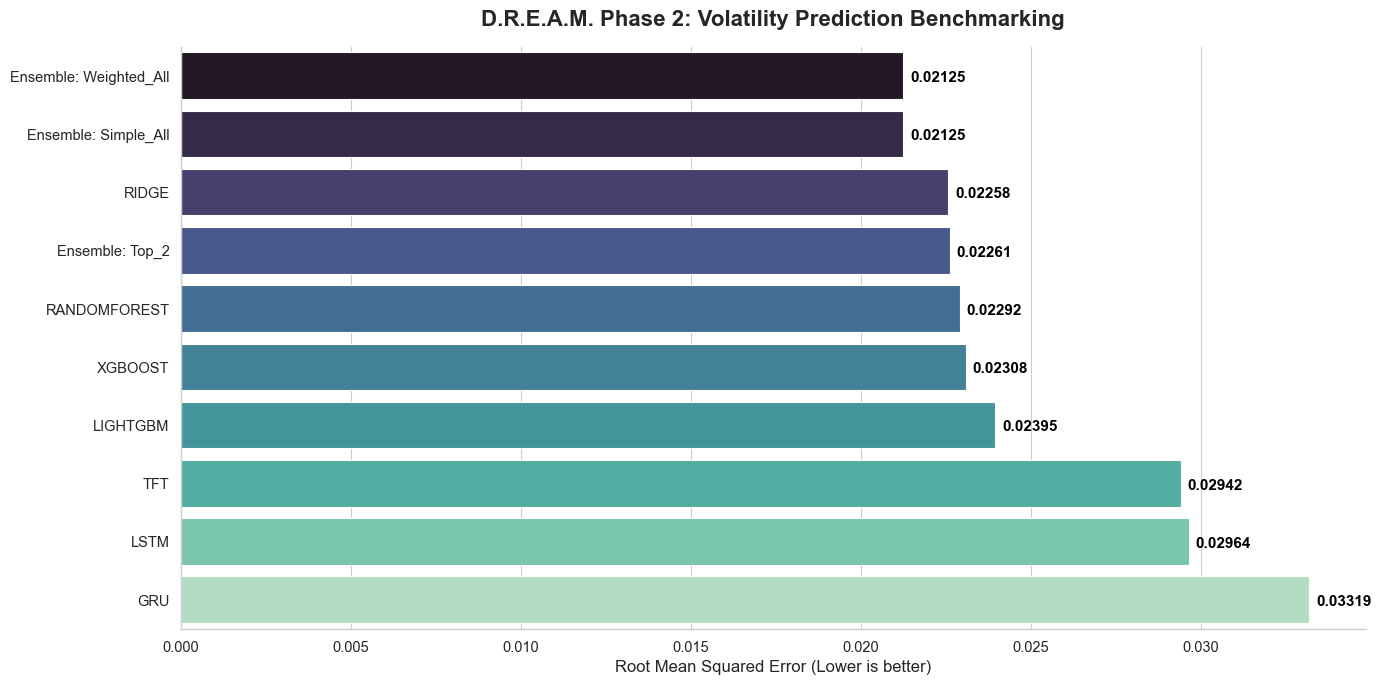

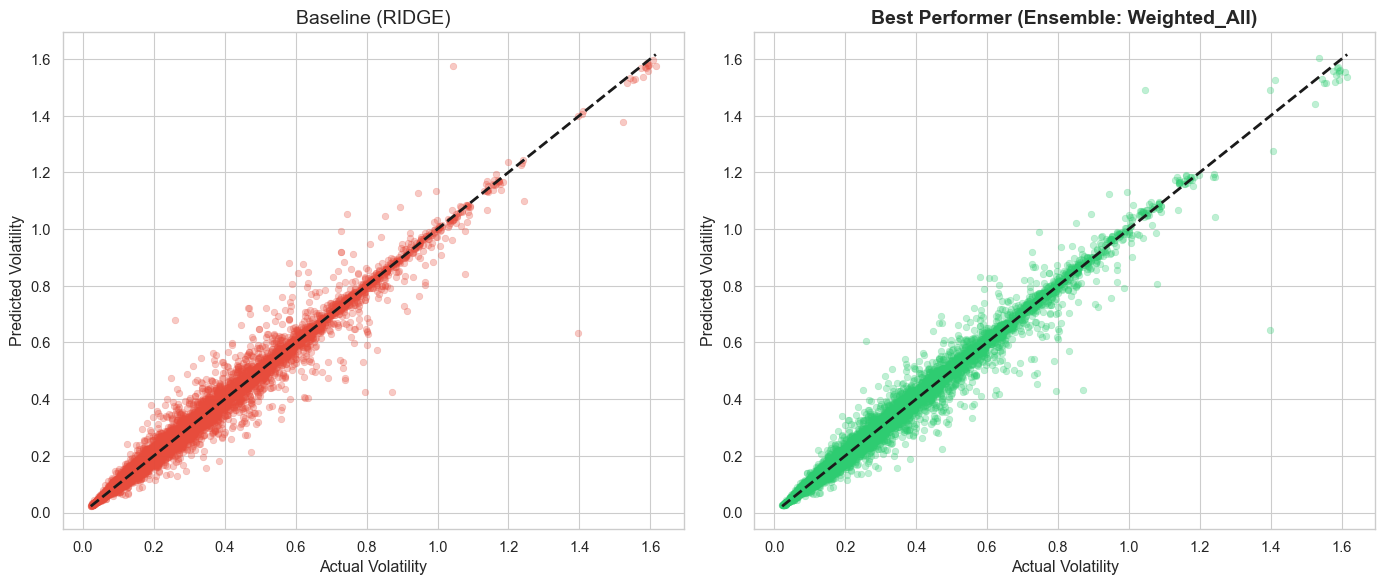

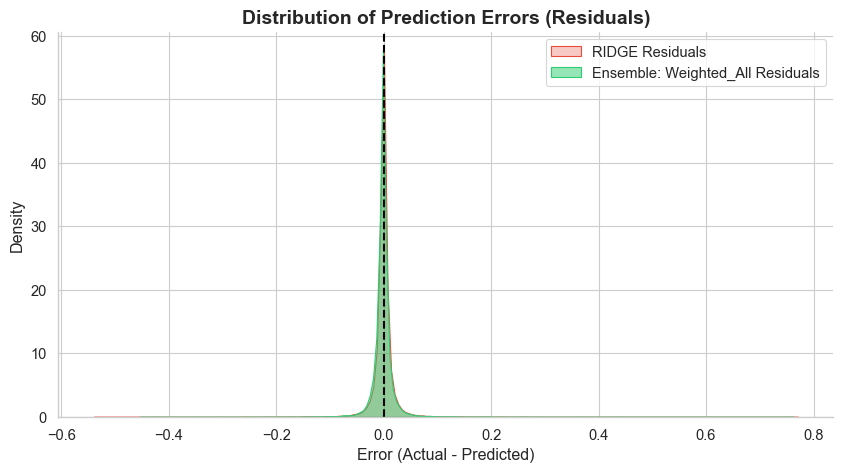

In [9]:
# Dynamically select the best model based on RMSE sorting from previous cell
best_col_name = results_df.iloc[0]['Raw_Column']
best_model_name = results_df.iloc[0]['Model']

# Define a baseline (Ridge if exists, else the worst model)
baseline_col = 'Pred_RIDGE' if 'Pred_RIDGE' in eval_df.columns else results_df.iloc[-1]['Raw_Column']
baseline_name = baseline_col.replace('Pred_', '')

print(f"Plotting dynamically: Best Model ({best_model_name}) vs Baseline ({baseline_name})")

# 1. Barplot of RMSE Comparison
plt.figure(figsize=(14, 7))
ax = sns.barplot(x='RMSE', y='Model', data=results_df, palette='mako')
plt.title('D.R.E.A.M. Phase 2: Volatility Prediction Benchmarking', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Root Mean Squared Error (Lower is better)', fontsize=12)
plt.ylabel('')

# Add value labels to bars
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.0002, p.get_y() + p.get_height()/2. + 0.1, 
             f'{width:.5f}', ha="left", fontsize=11, color='black', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

# 2. Scatter Plot: Actual vs Predicted
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=eval_df['Actual'], y=eval_df[baseline_col], alpha=0.3, color='#e74c3c', edgecolor=None)
plt.plot([eval_df['Actual'].min(), eval_df['Actual'].max()], 
         [eval_df['Actual'].min(), eval_df['Actual'].max()], 'k--', lw=2)
plt.title(f'Baseline ({baseline_name})', fontsize=14)
plt.xlabel('Actual Volatility')
plt.ylabel('Predicted Volatility')

plt.subplot(1, 2, 2)
sns.scatterplot(x=eval_df['Actual'], y=eval_df[best_col_name], alpha=0.3, color='#2ecc71', edgecolor=None)
plt.plot([eval_df['Actual'].min(), eval_df['Actual'].max()], 
         [eval_df['Actual'].min(), eval_df['Actual'].max()], 'k--', lw=2)
plt.title(f'Best Performer ({best_model_name})', fontsize=14, fontweight='bold')
plt.xlabel('Actual Volatility')
plt.ylabel('Predicted Volatility')

plt.tight_layout()
plt.show()

# 3. Error Distribution (Residuals)
plt.figure(figsize=(10, 5))
sns.kdeplot(eval_df['Actual'] - eval_df[baseline_col], label=f'{baseline_name} Residuals', fill=True, color='#e74c3c', alpha=0.3)
sns.kdeplot(eval_df['Actual'] - eval_df[best_col_name], label=f'{best_model_name} Residuals', fill=True, color='#2ecc71', alpha=0.5)
plt.title('Distribution of Prediction Errors (Residuals)', fontsize=14, fontweight='bold')
plt.xlabel('Error (Actual - Predicted)')
plt.ylabel('Density')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
plt.legend()
sns.despine()
plt.show()

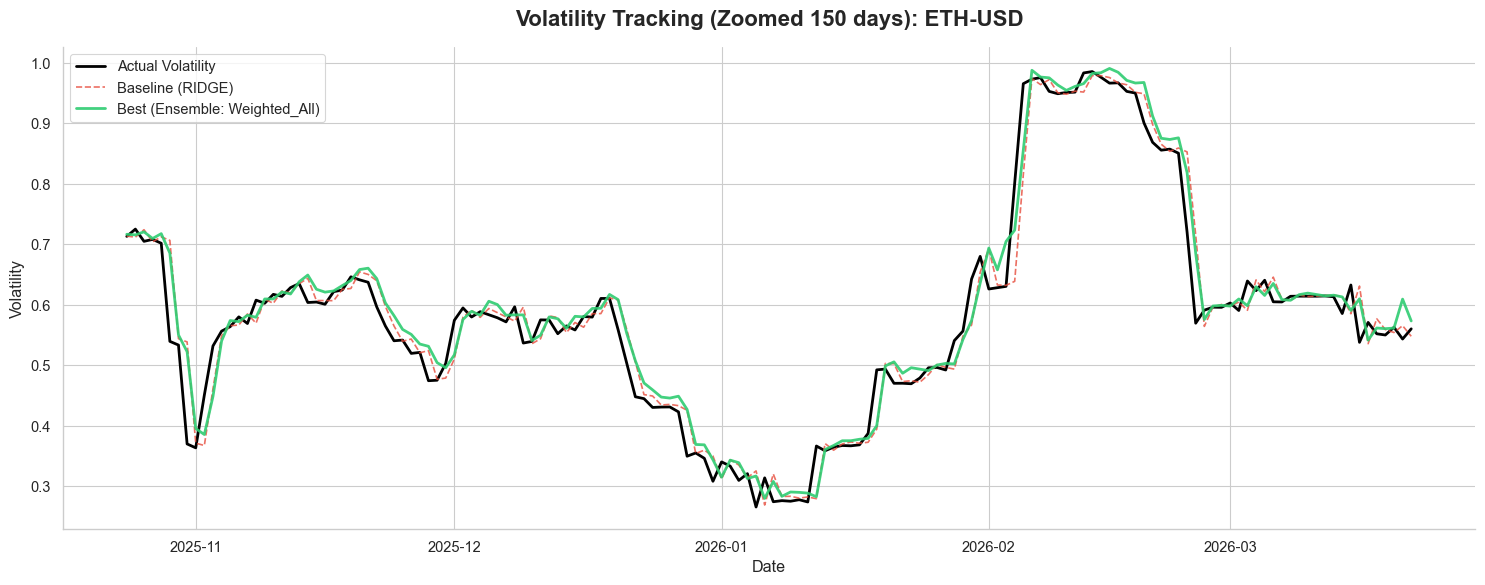

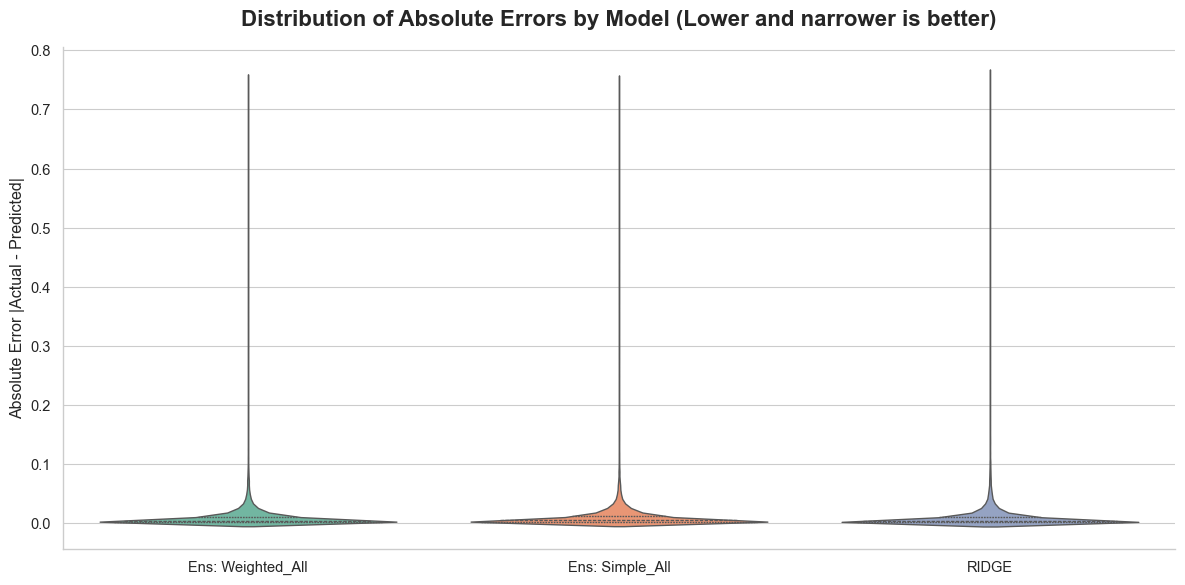

In [10]:
# 1. Time Series Plot (Actual vs Predicted for a representative asset)
# Let's pick the most volatile asset in the test set to see how the model tracks spikes
ticker_vols = eval_df.groupby('ticker')['Actual'].std()
sample_ticker = ticker_vols.idxmax() # Gets the ticker with highest variance
sample_df = eval_df[eval_df['ticker'] == sample_ticker].sort_values('Date')

# To make the plot readable, let's zoom in on the last 150 trading days of that ticker
zoom_df = sample_df.tail(150)

plt.figure(figsize=(15, 6))
plt.plot(zoom_df['Date'], zoom_df['Actual'], label='Actual Volatility', color='black', linewidth=2)
plt.plot(zoom_df['Date'], zoom_df[baseline_col], label=f'Baseline ({baseline_name})', color='#e74c3c', linestyle='--', alpha=0.8)
plt.plot(zoom_df['Date'], zoom_df[best_col_name], label=f'Best ({best_model_name})', color='#2ecc71', linewidth=2, alpha=0.9)

plt.title(f'Volatility Tracking (Zoomed 150 days): {sample_ticker}', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend(loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()

# 2. Violin Plot of Absolute Errors (Top Models vs Baseline)
# This shows the distribution and outliers of errors for the best models
top_models_raw = results_df[results_df['Raw_Column'].isin(eval_df.columns)].head(3)['Raw_Column'].tolist()
if baseline_col not in top_models_raw:
    top_models_raw.append(baseline_col)

# Calculate absolute errors
abs_err_df = pd.DataFrame()
for col in top_models_raw:
    clean_name = col.replace('Pred_', '').replace('Ens_', 'Ens: ')
    abs_err_df[clean_name] = np.abs(eval_df['Actual'] - eval_df[col])

# Melt dataframe for seaborn formatting
abs_err_melted = abs_err_df.melt(var_name='Model', value_name='Absolute Error')

plt.figure(figsize=(12, 6))
sns.violinplot(x='Model', y='Absolute Error', data=abs_err_melted, palette='Set2', inner='quartile')
plt.title('Distribution of Absolute Errors by Model (Lower and narrower is better)', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Absolute Error |Actual - Predicted|')
plt.xlabel('')
sns.despine()
plt.tight_layout()
plt.show()

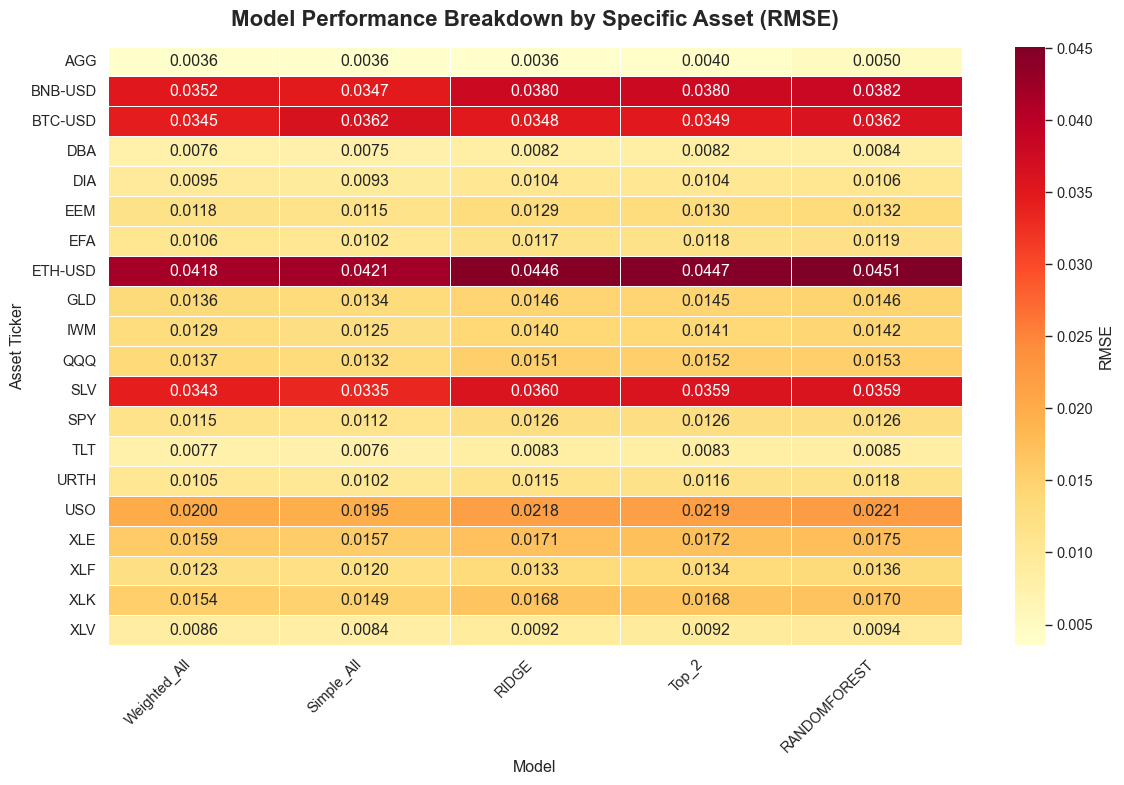

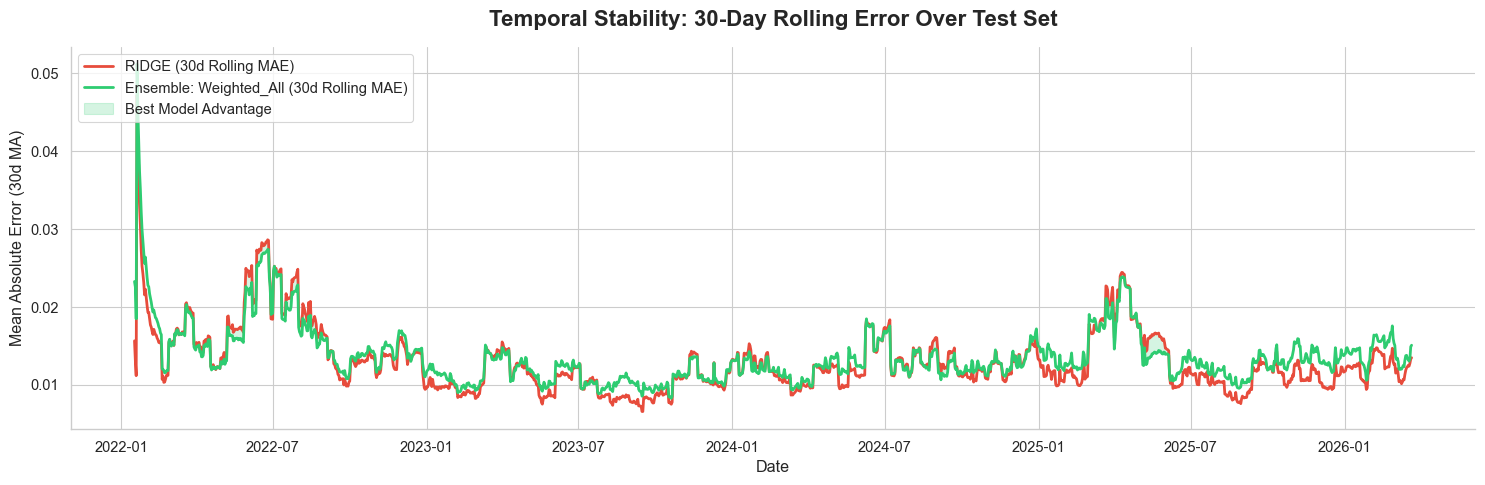

In [11]:
# 1. Heatmap: RMSE by Ticker and Top Models
# Helps answer: "Are some markets fundamentally harder to predict than others?"
top_5_cols = results_df[results_df['Raw_Column'].isin(eval_df.columns)].head(5)['Raw_Column'].tolist()

heatmap_data = []
for ticker, group in eval_df.groupby('ticker'):
    row = {'Ticker': ticker}
    for col in top_5_cols:
        clean_name = col.replace('Pred_', '').replace('Ens_', '')
        row[clean_name] = np.sqrt(mean_squared_error(group['Actual'], group[col]))
    heatmap_data.append(row)

heatmap_df = pd.DataFrame(heatmap_data).set_index('Ticker')

plt.figure(figsize=(12, 8))
# Annotate values, use a colormap where red is high error, green/blue is low error
sns.heatmap(heatmap_df, annot=True, fmt=".4f", cmap="YlOrRd", linewidths=.5, cbar_kws={'label': 'RMSE'})
plt.title('Model Performance Breakdown by Specific Asset (RMSE)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Model')
plt.ylabel('Asset Ticker')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. Temporal Stability: 30-Day Rolling Mean Absolute Error (MAE)
# Helps answer: "Did the models degrade during specific market periods?"
# Group by date to get daily average cross-sectional error
daily_errors = eval_df.groupby('Date').apply(
    lambda x: pd.Series({
        'Baseline_MAE': mean_absolute_error(x['Actual'], x[baseline_col]),
        'BestModel_MAE': mean_absolute_error(x['Actual'], x[best_col_name])
    })
).reset_index()

# Calculate 30-day moving average to smooth the noise
daily_errors['Baseline_Rolling'] = daily_errors['Baseline_MAE'].rolling(window=30, min_periods=1).mean()
daily_errors['BestModel_Rolling'] = daily_errors['BestModel_MAE'].rolling(window=30, min_periods=1).mean()

plt.figure(figsize=(15, 5))
plt.plot(daily_errors['Date'], daily_errors['Baseline_Rolling'], label=f'{baseline_name} (30d Rolling MAE)', color='#e74c3c', linewidth=2)
plt.plot(daily_errors['Date'], daily_errors['BestModel_Rolling'], label=f'{best_model_name} (30d Rolling MAE)', color='#2ecc71', linewidth=2)

# Fill the area where the Best Model outperforms the Baseline
plt.fill_between(daily_errors['Date'], daily_errors['BestModel_Rolling'], daily_errors['Baseline_Rolling'], 
                 where=(daily_errors['BestModel_Rolling'] < daily_errors['Baseline_Rolling']), 
                 interpolate=True, color='#2ecc71', alpha=0.2, label='Best Model Advantage')

plt.title('Temporal Stability: 30-Day Rolling Error Over Test Set', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Date')
plt.ylabel('Mean Absolute Error (30d MA)')
plt.legend(loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()